# Precision-Recall Quadrants: Diagnose & Fix Your Model
### Understanding All 4 Scenarios + Root Causes + Solutions

**Video Title:** *High-P High-R vs Low-P Low-R: What's Wrong & How to Fix*

**The 4 Quadrants:**
- 🟢 High Precision, High Recall → **IDEAL** (ship it!)
- 🟡 High Precision, Low Recall → **CONSERVATIVE** (too careful)
- 🟠 Low Precision, High Recall → **AGGRESSIVE** (too loose)
- 🔴 Low Precision, Low Recall → **BROKEN** (useless model)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch, Circle, FancyArrowPatch
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
import seaborn as sns

plt.style.use('dark_background')
np.random.seed(42)

## 1. The 4 Quadrants: Visual Overview

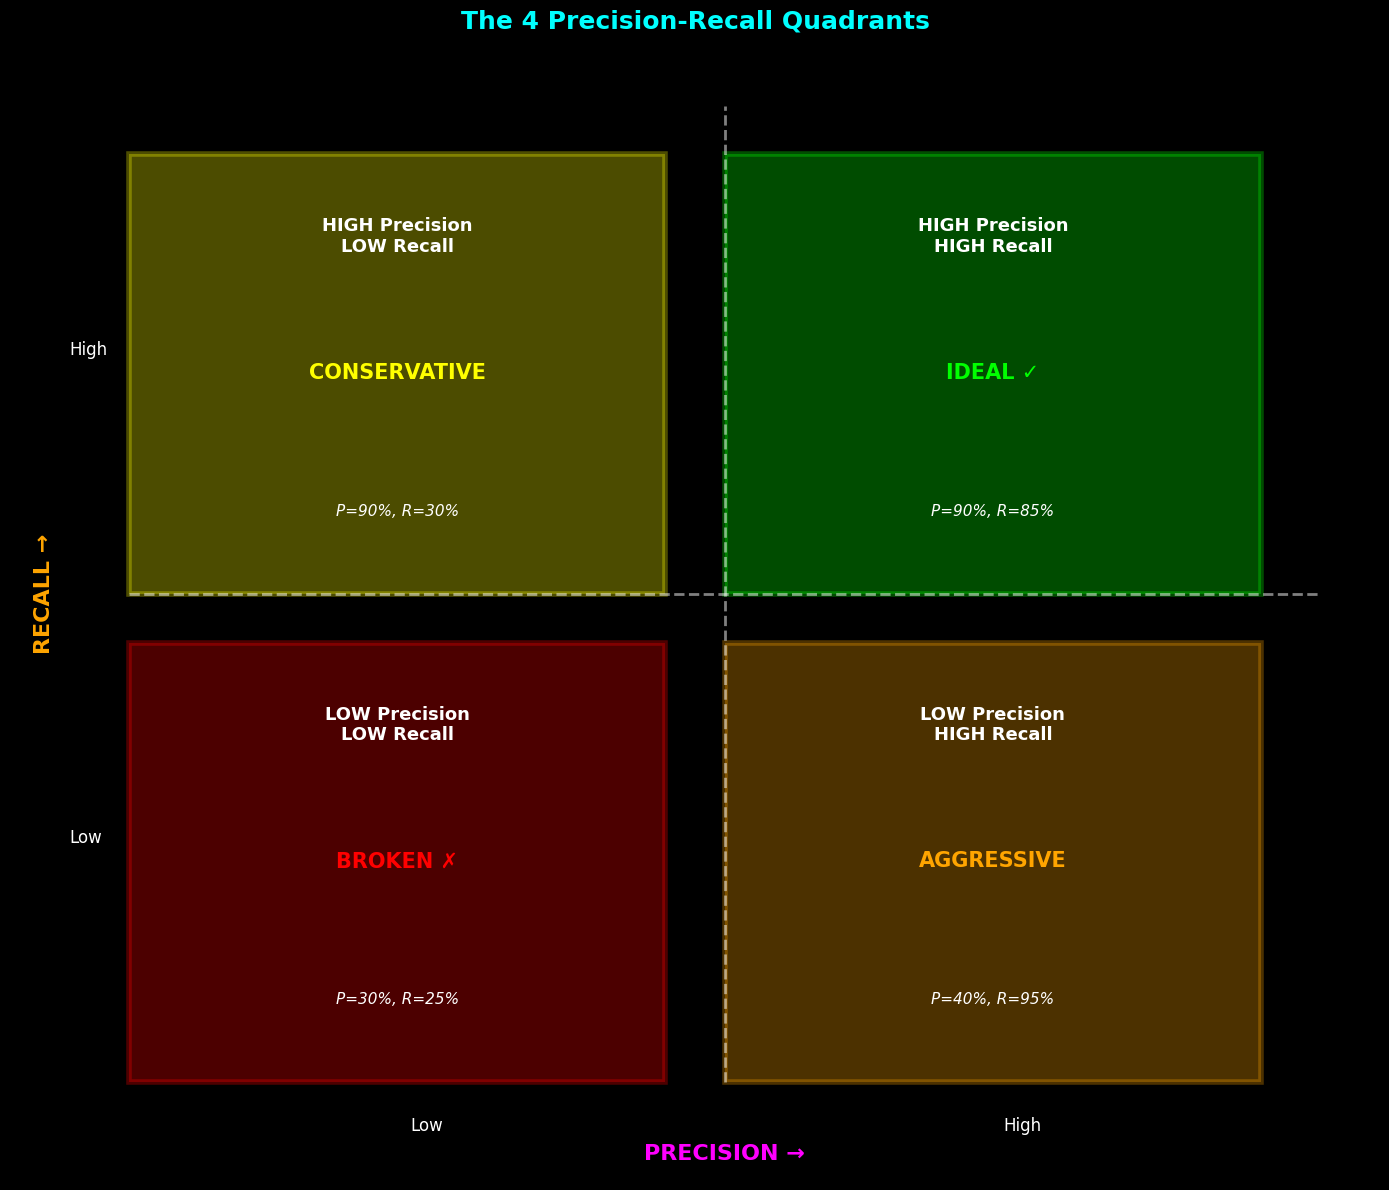

The 4 Scenarios:
🟢 HIGH P, HIGH R: Perfect! Model works great
🟡 HIGH P, LOW R:  Conservative - misses many positives
🟠 LOW P, HIGH R:  Aggressive - too many false alarms
🔴 LOW P, LOW R:   Broken - model is useless


In [2]:
fig, ax = plt.subplots(figsize=(14, 12))

# Draw quadrants
quadrants = [
    {'pos': (0.5, 0.5), 'color': 'lime', 'label': 'HIGH Precision\nHIGH Recall',
     'status': 'IDEAL ✓', 'example': 'P=90%, R=85%'},
    {'pos': (0.0, 0.5), 'color': 'yellow', 'label': 'HIGH Precision\nLOW Recall',
     'status': 'CONSERVATIVE', 'example': 'P=90%, R=30%'},
    {'pos': (0.5, 0.0), 'color': 'orange', 'label': 'LOW Precision\nHIGH Recall',
     'status': 'AGGRESSIVE', 'example': 'P=40%, R=95%'},
    {'pos': (0.0, 0.0), 'color': 'red', 'label': 'LOW Precision\nLOW Recall',
     'status': 'BROKEN ✗', 'example': 'P=30%, R=25%'}
]

for quad in quadrants:
    rect = Rectangle(quad['pos'], 0.45, 0.45, 
                    facecolor=quad['color'], alpha=0.3,
                    edgecolor=quad['color'], linewidth=4)
    ax.add_patch(rect)
    
    # Label
    ax.text(quad['pos'][0] + 0.225, quad['pos'][1] + 0.35, quad['label'],
           ha='center', fontsize=13, fontweight='bold', color='white')
    
    # Status
    ax.text(quad['pos'][0] + 0.225, quad['pos'][1] + 0.22, quad['status'],
           ha='center', fontsize=15, fontweight='bold', color=quad['color'])
    
    # Example
    ax.text(quad['pos'][0] + 0.225, quad['pos'][1] + 0.08, quad['example'],
           ha='center', fontsize=11, color='white', style='italic')

# Axes
ax.plot([0, 1], [0.5, 0.5], 'w--', linewidth=2, alpha=0.5)
ax.plot([0.5, 0.5], [0, 1], 'w--', linewidth=2, alpha=0.5)

# Axis labels
ax.text(0.5, -0.08, 'PRECISION →', ha='center', fontsize=16, 
       fontweight='bold', color='magenta')
ax.text(-0.08, 0.5, 'RECALL →', va='center', fontsize=16, 
       fontweight='bold', color='orange', rotation=90)

# Threshold indicators
ax.text(0.25, -0.05, 'Low', ha='center', fontsize=12, color='white')
ax.text(0.75, -0.05, 'High', ha='center', fontsize=12, color='white')
ax.text(-0.05, 0.25, 'Low', va='center', fontsize=12, color='white')
ax.text(-0.05, 0.75, 'High', va='center', fontsize=12, color='white')

ax.set_xlim(-0.1, 1.05)
ax.set_ylim(-0.1, 1.05)
ax.set_title('The 4 Precision-Recall Quadrants', 
            fontsize=18, fontweight='bold', pad=20, color='cyan')
ax.axis('off')

plt.tight_layout()
plt.show()

print("The 4 Scenarios:")
print("="*70)
print("🟢 HIGH P, HIGH R: Perfect! Model works great")
print("🟡 HIGH P, LOW R:  Conservative - misses many positives")
print("🟠 LOW P, HIGH R:  Aggressive - too many false alarms")
print("🔴 LOW P, LOW R:   Broken - model is useless")
print("="*70)

## 2. Scenario 1: HIGH Precision, HIGH Recall (IDEAL)
**The goal - everything working perfectly!**

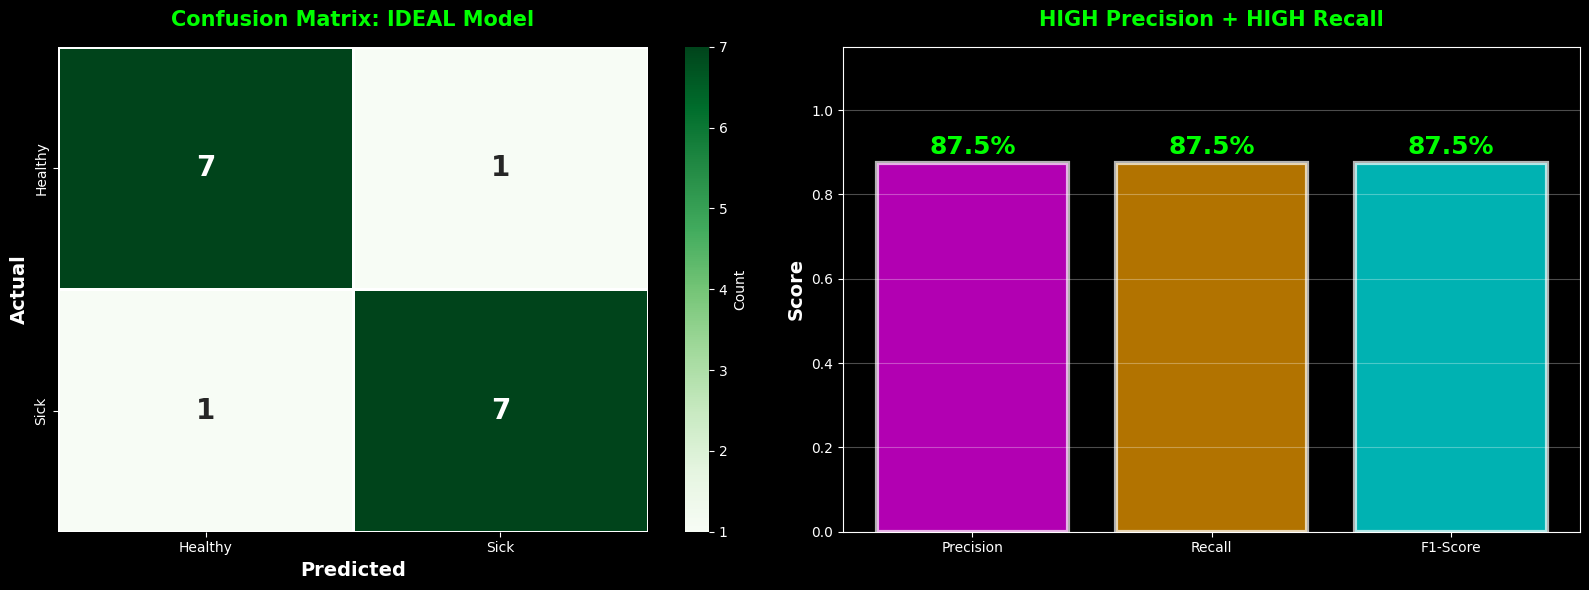

✓ IDEAL MODEL (High P, High R):
TP=7, FP=1, FN=1, TN=7
Precision: 87.5% - When predicts sick, usually right
Recall:    87.5% - Catches most sick patients
F1-Score:  87.5% - Balanced and high

WHAT'S WORKING:
- Low FP: Few false alarms
- Low FN: Few missed cases
- This is the GOAL for any model!

HOW TO ACHIEVE:
✓ Good quality training data (sufficient & diverse)
✓ Well-tuned model (proper features, hyperparameters)
✓ Optimal threshold (via ROC/PR curve analysis)
✓ Feature engineering (relevant, informative features)


In [3]:
# Simulate ideal model
y_true_ideal = np.array([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])  # 8 sick, 8 healthy
y_pred_ideal = np.array([1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0])  # Good predictions

tn, fp, fn, tp = confusion_matrix(y_true_ideal, y_pred_ideal).ravel()
prec_ideal = precision_score(y_true_ideal, y_pred_ideal)
rec_ideal = recall_score(y_true_ideal, y_pred_ideal)
f1_ideal = f1_score(y_true_ideal, y_pred_ideal)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
cm = confusion_matrix(y_true_ideal, y_pred_ideal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Healthy', 'Sick'],
            yticklabels=['Healthy', 'Sick'],
            cbar_kws={'label': 'Count'},
            linewidths=2, linecolor='white',
            ax=axes[0], annot_kws={'size': 20, 'weight': 'bold'})
axes[0].set_xlabel('Predicted', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=14, fontweight='bold')
axes[0].set_title('Confusion Matrix: IDEAL Model', 
                 fontsize=15, fontweight='bold', color='lime', pad=15)

# Metrics
metrics = ['Precision', 'Recall', 'F1-Score']
values = [prec_ideal, rec_ideal, f1_ideal]
bars = axes[1].bar(metrics, values, color=['magenta', 'orange', 'cyan'], 
                  alpha=0.7, edgecolor='white', linewidth=3)

for bar, val in zip(bars, values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{val:.1%}', ha='center', fontsize=18, 
                fontweight='bold', color='lime')

axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('Score', fontsize=14, fontweight='bold')
axes[1].set_title('HIGH Precision + HIGH Recall', 
                 fontsize=15, fontweight='bold', color='lime', pad=15)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ IDEAL MODEL (High P, High R):")
print("="*70)
print(f"TP={tp}, FP={fp}, FN={fn}, TN={tn}")
print(f"Precision: {prec_ideal:.1%} - When predicts sick, usually right")
print(f"Recall:    {rec_ideal:.1%} - Catches most sick patients")
print(f"F1-Score:  {f1_ideal:.1%} - Balanced and high")
print("\nWHAT'S WORKING:")
print("- Low FP: Few false alarms")
print("- Low FN: Few missed cases")
print("- This is the GOAL for any model!")
print("\nHOW TO ACHIEVE:")
print("✓ Good quality training data (sufficient & diverse)")
print("✓ Well-tuned model (proper features, hyperparameters)")
print("✓ Optimal threshold (via ROC/PR curve analysis)")
print("✓ Feature engineering (relevant, informative features)")
print("="*70)

## 3. Scenario 2: HIGH Precision, LOW Recall (CONSERVATIVE)
**Too careful - misses many positives**

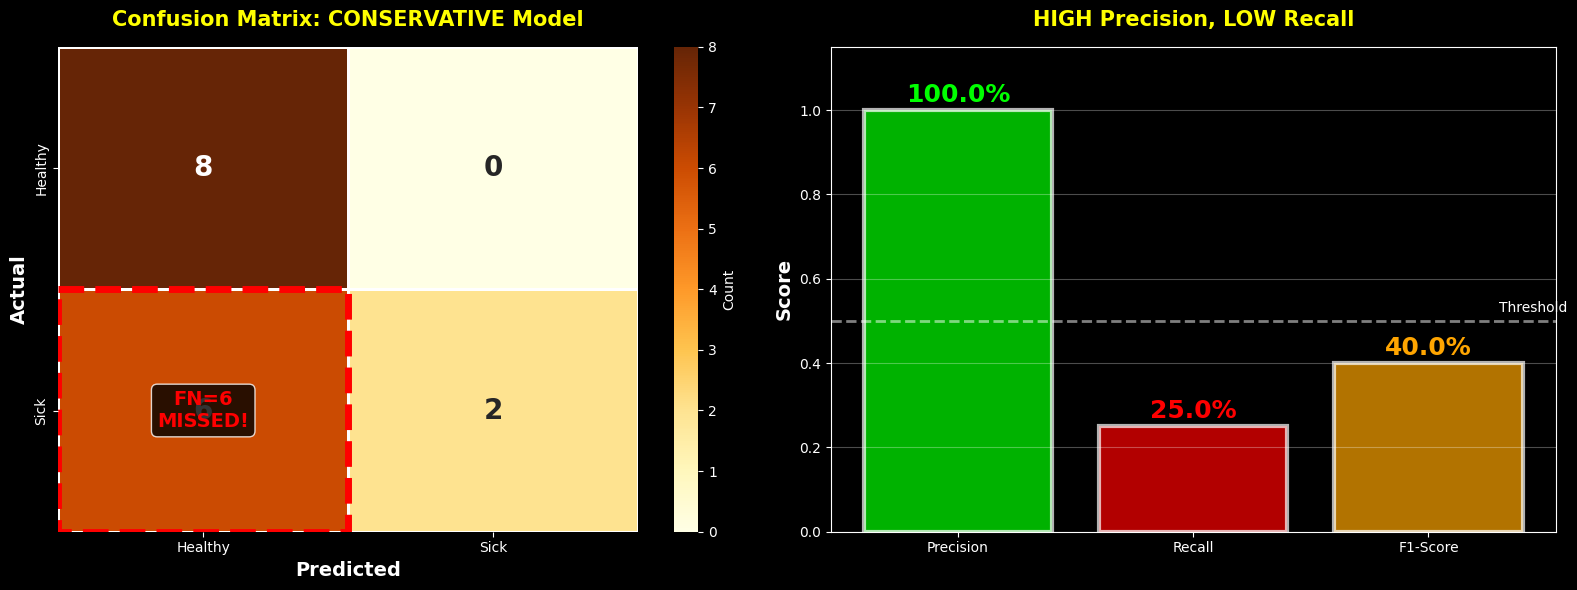

⚠️ CONSERVATIVE MODEL (High P, Low R):
TP=2, FP=0, FN=6, TN=8
Precision: 100.0% - When predicts sick, it's right
Recall:    25.0% - But catches only 25% of sick! ✗
F1-Score:  40.0% - Low due to poor recall

WHAT'S WRONG:
- High FN (6): Missing 6 sick patients! DANGEROUS in medical context
- Low FP: Good, but doesn't compensate for high FN
- Model is TOO CONSERVATIVE - threshold too high

WHY THIS HAPPENS:
1. THRESHOLD TOO HIGH:
   - Model requires very high confidence to predict positive
   - Only 'obvious' cases get flagged
   - Border cases classified as negative

2. INSUFFICIENT TRAINING DATA for positive class:
   - Model hasn't seen enough positive examples
   - Can't recognize diverse manifestations of positive class
   - Generalizes poorly to unseen positive cases

3. CLASS IMBALANCE:
   - Training data has way more negatives than positives
   - Model biased toward predicting negative

4. POOR FEATURE REPRESENTATION:
   - Features don't capture positive class well
   - Hard for 

In [4]:
# Simulate conservative model (high threshold)
y_true_cons = np.array([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])  # 8 sick, 8 healthy
y_pred_cons = np.array([1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])  # Only predicts 2 sick

tn, fp, fn, tp = confusion_matrix(y_true_cons, y_pred_cons).ravel()
prec_cons = precision_score(y_true_cons, y_pred_cons)
rec_cons = recall_score(y_true_cons, y_pred_cons)
f1_cons = f1_score(y_true_cons, y_pred_cons)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
cm = confusion_matrix(y_true_cons, y_pred_cons)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr', 
            xticklabels=['Healthy', 'Sick'],
            yticklabels=['Healthy', 'Sick'],
            cbar_kws={'label': 'Count'},
            linewidths=2, linecolor='white',
            ax=axes[0], annot_kws={'size': 20, 'weight': 'bold'})
axes[0].set_xlabel('Predicted', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=14, fontweight='bold')
axes[0].set_title('Confusion Matrix: CONSERVATIVE Model', 
                 fontsize=15, fontweight='bold', color='yellow', pad=15)

# Highlight the problem
axes[0].add_patch(Rectangle((0, 1), 1, 1, fill=False, 
                           edgecolor='red', linewidth=5, linestyle='--'))
axes[0].text(0.5, 1.5, f'FN={fn}\nMISSED!', ha='center', va='center',
            fontsize=14, fontweight='bold', color='red',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.8))

# Metrics
metrics = ['Precision', 'Recall', 'F1-Score']
values = [prec_cons, rec_cons, f1_cons]
colors = ['lime', 'red', 'orange']
bars = axes[1].bar(metrics, values, color=colors, 
                  alpha=0.7, edgecolor='white', linewidth=3)

for bar, val, color in zip(bars, values, colors):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{val:.1%}', ha='center', fontsize=18, 
                fontweight='bold', color=color)

axes[1].axhline(0.5, color='white', linestyle='--', linewidth=2, alpha=0.5)
axes[1].text(2.3, 0.52, 'Threshold', fontsize=10, color='white')

axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('Score', fontsize=14, fontweight='bold')
axes[1].set_title('HIGH Precision, LOW Recall', 
                 fontsize=15, fontweight='bold', color='yellow', pad=15)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("⚠️ CONSERVATIVE MODEL (High P, Low R):")
print("="*70)
print(f"TP={tp}, FP={fp}, FN={fn}, TN={tn}")
print(f"Precision: {prec_cons:.1%} - When predicts sick, it's right")
print(f"Recall:    {rec_cons:.1%} - But catches only {rec_cons:.0%} of sick! ✗")
print(f"F1-Score:  {f1_cons:.1%} - Low due to poor recall")
print("\nWHAT'S WRONG:")
print(f"- High FN ({fn}): Missing {fn} sick patients! DANGEROUS in medical context")
print("- Low FP: Good, but doesn't compensate for high FN")
print("- Model is TOO CONSERVATIVE - threshold too high")
print("\nWHY THIS HAPPENS:")
print("1. THRESHOLD TOO HIGH:")
print("   - Model requires very high confidence to predict positive")
print("   - Only 'obvious' cases get flagged")
print("   - Border cases classified as negative")
print("\n2. INSUFFICIENT TRAINING DATA for positive class:")
print("   - Model hasn't seen enough positive examples")
print("   - Can't recognize diverse manifestations of positive class")
print("   - Generalizes poorly to unseen positive cases")
print("\n3. CLASS IMBALANCE:")
print("   - Training data has way more negatives than positives")
print("   - Model biased toward predicting negative")
print("\n4. POOR FEATURE REPRESENTATION:")
print("   - Features don't capture positive class well")
print("   - Hard for model to distinguish positives from negatives")
print("\nMEANING OF 'CONSERVATIVE':")
print("- Model is RISK-AVERSE")
print("- Only predicts positive when VERY confident")
print("- Prefers false negatives over false positives")
print("- Like a doctor who only diagnoses cancer with 99% certainty")
print("\nHOW TO FIX:")
print("✓ LOWER THE THRESHOLD:")
print("  - Adjust decision boundary (e.g., 0.5 → 0.3)")
print("  - Use ROC curve to find optimal threshold")
print("  - Sacrifice some precision to gain recall")
print("\n✓ COLLECT MORE POSITIVE CLASS DATA:")
print("  - Get more examples of sick patients")
print("  - Ensure diversity in positive samples")
print("  - Model learns better positive class patterns")
print("\n✓ DATA AUGMENTATION for positive class:")
print("  - Synthetic minority oversampling (SMOTE)")
print("  - Generate synthetic positive examples")
print("  - Balance the training distribution")
print("\n✓ CLASS WEIGHTS:")
print("  - Set higher weight for positive class")
print("  - Penalize FN more than FP during training")
print("  - E.g., class_weight='balanced' in sklearn")
print("\n✓ BETTER FEATURES for positive class:")
print("  - Feature engineering specific to positives")
print("  - Domain knowledge to capture positive indicators")
print("="*70)

## 4. Scenario 3: LOW Precision, HIGH Recall (AGGRESSIVE)
**Too loose - many false alarms**

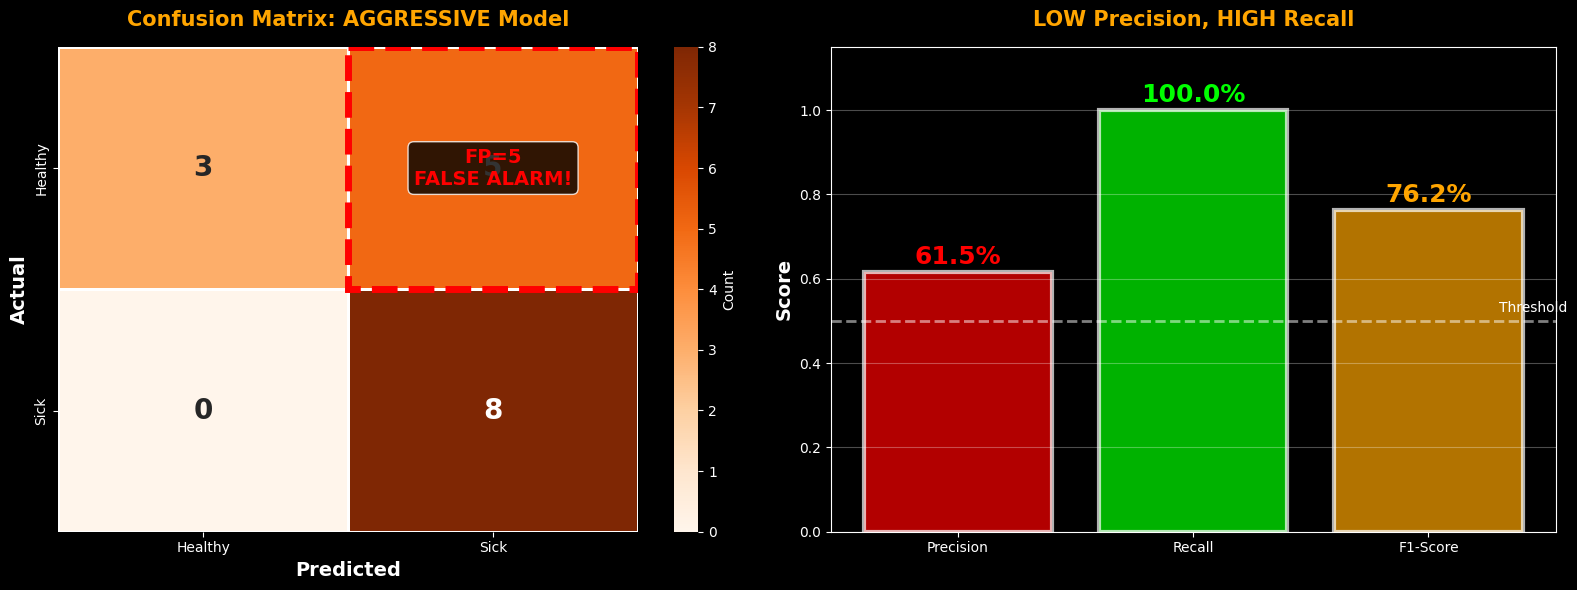

⚠️ AGGRESSIVE MODEL (Low P, High R):
TP=8, FP=5, FN=0, TN=3
Precision: 61.5% - Many false alarms! ✗
Recall:    100.0% - Catches all sick patients
F1-Score:  76.2% - Moderate due to poor precision

WHAT'S WRONG:
- High FP (5): Too many false alarms
- Low FN: Good - not missing sick patients
- Model is TOO AGGRESSIVE - threshold too low

WHY THIS HAPPENS:
1. THRESHOLD TOO LOW:
   - Model predicts positive with low confidence
   - 'When in doubt, say positive'
   - Many healthy people flagged as sick

2. MODEL OVERFITS TO POSITIVE CLASS:
   - Too sensitive to positive indicators
   - Sees positives everywhere

3. POOR NEGATIVE CLASS REPRESENTATION:
   - Not enough negative class training data
   - Can't distinguish negatives well

HOW TO FIX:
✓ RAISE THE THRESHOLD:
  - Require higher confidence for positive prediction
  - E.g., 0.3 → 0.5 or 0.7
  - Reduce false alarms

✓ COLLECT MORE NEGATIVE CLASS DATA:
  - More examples of healthy patients
  - Better negative class boundary

✓ REGULARIZ

In [5]:
# Simulate aggressive model (low threshold)
y_true_agg = np.array([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])  # 8 sick, 8 healthy
y_pred_agg = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0])  # Predicts 13 sick

tn, fp, fn, tp = confusion_matrix(y_true_agg, y_pred_agg).ravel()
prec_agg = precision_score(y_true_agg, y_pred_agg)
rec_agg = recall_score(y_true_agg, y_pred_agg)
f1_agg = f1_score(y_true_agg, y_pred_agg)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
cm = confusion_matrix(y_true_agg, y_pred_agg)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Healthy', 'Sick'],
            yticklabels=['Healthy', 'Sick'],
            cbar_kws={'label': 'Count'},
            linewidths=2, linecolor='white',
            ax=axes[0], annot_kws={'size': 20, 'weight': 'bold'})
axes[0].set_xlabel('Predicted', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=14, fontweight='bold')
axes[0].set_title('Confusion Matrix: AGGRESSIVE Model', 
                 fontsize=15, fontweight='bold', color='orange', pad=15)

# Highlight the problem
axes[0].add_patch(Rectangle((1, 0), 1, 1, fill=False, 
                           edgecolor='red', linewidth=5, linestyle='--'))
axes[0].text(1.5, 0.5, f'FP={fp}\nFALSE ALARM!', ha='center', va='center',
            fontsize=14, fontweight='bold', color='red',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.8))

# Metrics
metrics = ['Precision', 'Recall', 'F1-Score']
values = [prec_agg, rec_agg, f1_agg]
colors = ['red', 'lime', 'orange']
bars = axes[1].bar(metrics, values, color=colors, 
                  alpha=0.7, edgecolor='white', linewidth=3)

for bar, val, color in zip(bars, values, colors):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{val:.1%}', ha='center', fontsize=18, 
                fontweight='bold', color=color)

axes[1].axhline(0.5, color='white', linestyle='--', linewidth=2, alpha=0.5)
axes[1].text(2.3, 0.52, 'Threshold', fontsize=10, color='white')

axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('Score', fontsize=14, fontweight='bold')
axes[1].set_title('LOW Precision, HIGH Recall', 
                 fontsize=15, fontweight='bold', color='orange', pad=15)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("⚠️ AGGRESSIVE MODEL (Low P, High R):")
print("="*70)
print(f"TP={tp}, FP={fp}, FN={fn}, TN={tn}")
print(f"Precision: {prec_agg:.1%} - Many false alarms! ✗")
print(f"Recall:    {rec_agg:.1%} - Catches all sick patients")
print(f"F1-Score:  {f1_agg:.1%} - Moderate due to poor precision")
print("\nWHAT'S WRONG:")
print(f"- High FP ({fp}): Too many false alarms")
print("- Low FN: Good - not missing sick patients")
print("- Model is TOO AGGRESSIVE - threshold too low")
print("\nWHY THIS HAPPENS:")
print("1. THRESHOLD TOO LOW:")
print("   - Model predicts positive with low confidence")
print("   - 'When in doubt, say positive'")
print("   - Many healthy people flagged as sick")
print("\n2. MODEL OVERFITS TO POSITIVE CLASS:")
print("   - Too sensitive to positive indicators")
print("   - Sees positives everywhere")
print("\n3. POOR NEGATIVE CLASS REPRESENTATION:")
print("   - Not enough negative class training data")
print("   - Can't distinguish negatives well")
print("\nHOW TO FIX:")
print("✓ RAISE THE THRESHOLD:")
print("  - Require higher confidence for positive prediction")
print("  - E.g., 0.3 → 0.5 or 0.7")
print("  - Reduce false alarms")
print("\n✓ COLLECT MORE NEGATIVE CLASS DATA:")
print("  - More examples of healthy patients")
print("  - Better negative class boundary")
print("\n✓ REGULARIZATION:")
print("  - L1/L2 to prevent overfitting")
print("  - Reduce model complexity")
print("\n✓ FEATURE SELECTION:")
print("  - Remove noisy features")
print("  - Focus on most discriminative features")
print("="*70)

## 5. Scenario 4: LOW Precision, LOW Recall (BROKEN)
**Worst case - model is useless**

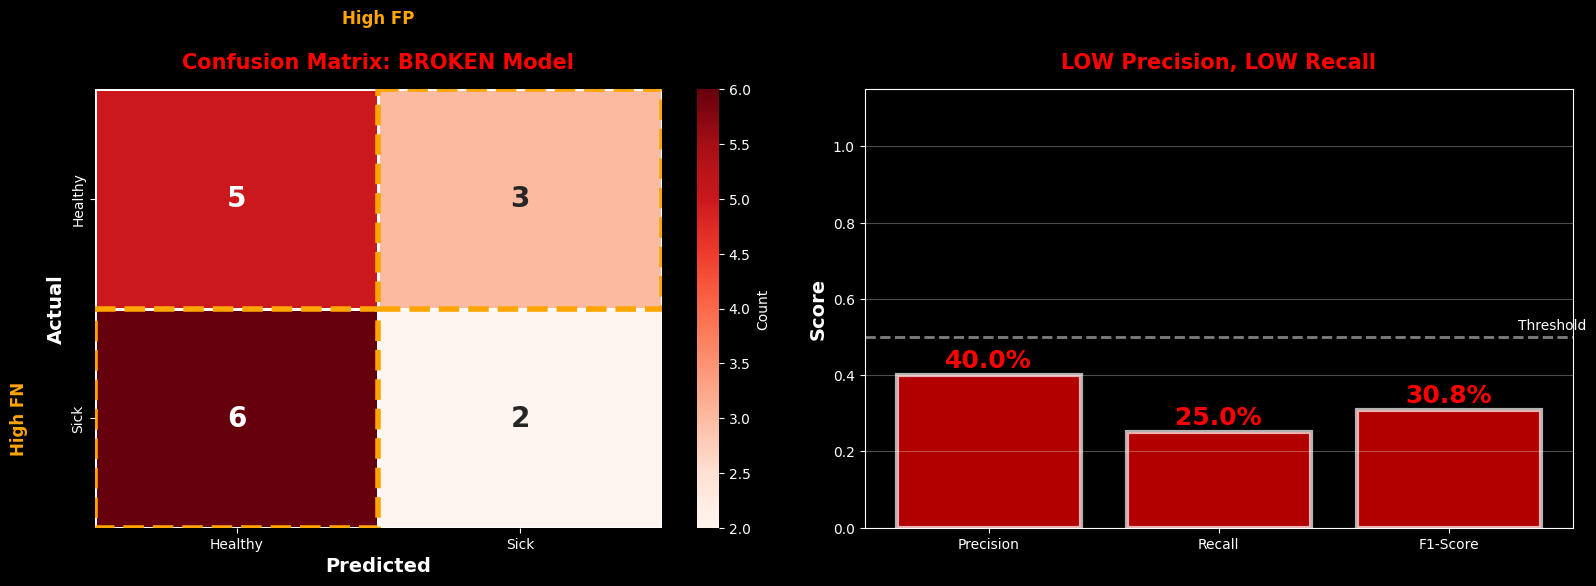

✗ BROKEN MODEL (Low P, Low R):
TP=2, FP=3, FN=6, TN=5
Precision: 40.0% - Most positives are wrong ✗
Recall:    25.0% - Missing most sick patients ✗
F1-Score:  30.8% - USELESS model

WHAT'S WRONG:
- High FP (3): False alarms
- High FN (6): Missing sick patients
- Model performs WORSE than random!

WHY THIS HAPPENS:
1. FUNDAMENTALLY BAD MODEL:
   - Wrong algorithm for the problem
   - Model can't learn the pattern
   - Like using linear model for non-linear data

2. TERRIBLE DATA QUALITY:
   - Insufficient training data (BOTH classes)
   - Noisy labels (wrong ground truth)
   - Missing critical features

3. FEATURE-LABEL MISMATCH:
   - Features don't predict the target
   - No signal in the data
   - Trying to predict unpredictable

4. SEVERE OVERFITTING OR UNDERFITTING:
   - Model memorizes noise (overfit)
   - Model too simple to capture pattern (underfit)

HOW TO FIX:
✓ START OVER - RETHINK THE PROBLEM:
  - Is the problem solvable with this data?
  - Do you have the right features?

✓

In [6]:
# Simulate broken model (random predictions)
y_true_broken = np.array([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])  # 8 sick, 8 healthy
y_pred_broken = np.array([0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0])  # Random, poor

tn, fp, fn, tp = confusion_matrix(y_true_broken, y_pred_broken).ravel()
prec_broken = precision_score(y_true_broken, y_pred_broken)
rec_broken = recall_score(y_true_broken, y_pred_broken)
f1_broken = f1_score(y_true_broken, y_pred_broken)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
cm = confusion_matrix(y_true_broken, y_pred_broken)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Healthy', 'Sick'],
            yticklabels=['Healthy', 'Sick'],
            cbar_kws={'label': 'Count'},
            linewidths=2, linecolor='white',
            ax=axes[0], annot_kws={'size': 20, 'weight': 'bold'})
axes[0].set_xlabel('Predicted', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=14, fontweight='bold')
axes[0].set_title('Confusion Matrix: BROKEN Model', 
                 fontsize=15, fontweight='bold', color='red', pad=15)

# Highlight both problems
axes[0].add_patch(Rectangle((1, 0), 1, 1, fill=False, 
                           edgecolor='orange', linewidth=4, linestyle='--'))
axes[0].add_patch(Rectangle((0, 1), 1, 1, fill=False, 
                           edgecolor='orange', linewidth=4, linestyle='--'))
axes[0].text(1, -0.3, 'High FP', ha='center', fontsize=12, 
            fontweight='bold', color='orange')
axes[0].text(-0.3, 1.5, 'High FN', va='center', fontsize=12, 
            fontweight='bold', color='orange', rotation=90)

# Metrics
metrics = ['Precision', 'Recall', 'F1-Score']
values = [prec_broken, rec_broken, f1_broken]
bars = axes[1].bar(metrics, values, color='red', 
                  alpha=0.7, edgecolor='white', linewidth=3)

for bar, val in zip(bars, values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{val:.1%}', ha='center', fontsize=18, 
                fontweight='bold', color='red')

axes[1].axhline(0.5, color='white', linestyle='--', linewidth=2, alpha=0.5)
axes[1].text(2.3, 0.52, 'Threshold', fontsize=10, color='white')

axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('Score', fontsize=14, fontweight='bold')
axes[1].set_title('LOW Precision, LOW Recall', 
                 fontsize=15, fontweight='bold', color='red', pad=15)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✗ BROKEN MODEL (Low P, Low R):")
print("="*70)
print(f"TP={tp}, FP={fp}, FN={fn}, TN={tn}")
print(f"Precision: {prec_broken:.1%} - Most positives are wrong ✗")
print(f"Recall:    {rec_broken:.1%} - Missing most sick patients ✗")
print(f"F1-Score:  {f1_broken:.1%} - USELESS model")
print("\nWHAT'S WRONG:")
print(f"- High FP ({fp}): False alarms")
print(f"- High FN ({fn}): Missing sick patients")
print("- Model performs WORSE than random!")
print("\nWHY THIS HAPPENS:")
print("1. FUNDAMENTALLY BAD MODEL:")
print("   - Wrong algorithm for the problem")
print("   - Model can't learn the pattern")
print("   - Like using linear model for non-linear data")
print("\n2. TERRIBLE DATA QUALITY:")
print("   - Insufficient training data (BOTH classes)")
print("   - Noisy labels (wrong ground truth)")
print("   - Missing critical features")
print("\n3. FEATURE-LABEL MISMATCH:")
print("   - Features don't predict the target")
print("   - No signal in the data")
print("   - Trying to predict unpredictable")
print("\n4. SEVERE OVERFITTING OR UNDERFITTING:")
print("   - Model memorizes noise (overfit)")
print("   - Model too simple to capture pattern (underfit)")
print("\nHOW TO FIX:")
print("✓ START OVER - RETHINK THE PROBLEM:")
print("  - Is the problem solvable with this data?")
print("  - Do you have the right features?")
print("\n✓ COLLECT MUCH MORE DATA:")
print("  - Both positive AND negative classes")
print("  - Ensure data quality and label correctness")
print("  - Aim for 10x more data if possible")
print("\n✓ BETTER FEATURES:")
print("  - Domain knowledge - what truly predicts the outcome?")
print("  - Feature engineering - create meaningful features")
print("  - Feature selection - remove noise")
print("\n✓ TRY DIFFERENT ALGORITHMS:")
print("  - Linear → Tree-based")
print("  - Simple → Deep learning")
print("  - Ensemble methods")
print("\n✓ CHECK DATA LEAKAGE:")
print("  - Are you accidentally using future information?")
print("  - Train-test contamination?")
print("\n✓ BASELINE COMPARISON:")
print("  - Compare with random classifier")
print("  - Compare with majority class baseline")
print("  - If can't beat baseline, problem with data!")
print("="*70)

## 6. Insufficient Training Data Impact on Recall
**Visualizing how lack of positive examples hurts recall**

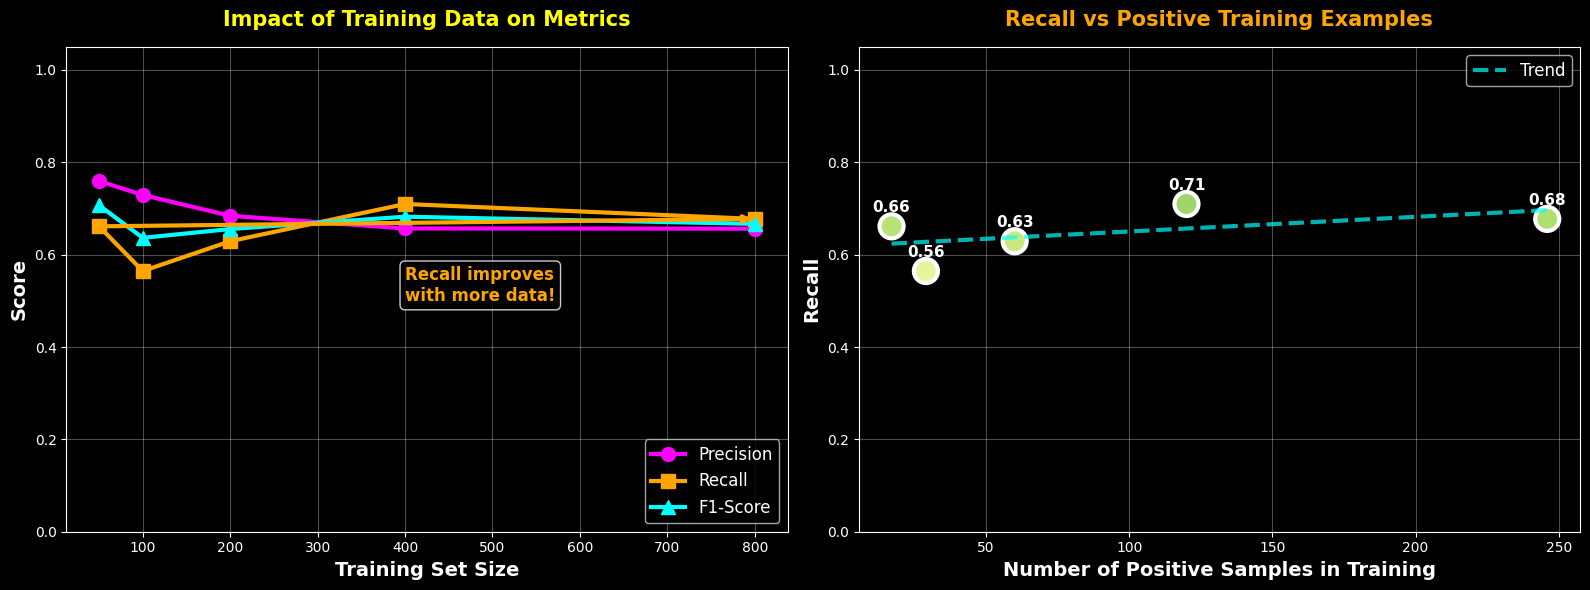


📊 TRAINING DATA SIZE IMPACT:
Train= 50 | Positives= 17 | P=0.76 | R=0.66 | F1=0.71
Train=100 | Positives= 29 | P=0.73 | R=0.56 | F1=0.64
Train=200 | Positives= 60 | P=0.68 | R=0.63 | F1=0.66
Train=400 | Positives=120 | P=0.66 | R=0.71 | F1=0.68
Train=800 | Positives=246 | P=0.66 | R=0.68 | F1=0.67

KEY INSIGHT: INSUFFICIENT TRAINING DATA → LOW RECALL
WHY?
1. Model hasn't seen enough positive examples
2. Can't learn diverse patterns of positive class
3. Becomes CONSERVATIVE - only predicts 'obvious' positives
4. Misses subtle or edge-case positives (high FN)

SOLUTION:
✓ Collect more positive class data
✓ Use data augmentation (SMOTE, etc.)
✓ Transfer learning from related tasks
✓ Class weights to amplify limited positive samples


In [7]:
# Simulate training with different amounts of data
np.random.seed(42)

# Generate full dataset
X_full, y_full = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=3,
    n_classes=2,
    weights=[0.7, 0.3],  # Imbalanced
    flip_y=0.1,
    random_state=42
)

# Test set (fixed)
X_test = X_full[800:]
y_test = y_full[800:]

# Different training set sizes
train_sizes = [50, 100, 200, 400, 800]
results = []

for size in train_sizes:
    X_train = X_full[:size]
    y_train = y_full[:size]
    
    # Count positive samples in training
    n_positives = np.sum(y_train == 1)
    
    # Train model
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        'train_size': size,
        'n_positives': n_positives,
        'precision': prec,
        'recall': rec,
        'f1': f1
    })

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Metrics vs training size
train_sizes_arr = [r['train_size'] for r in results]
precisions = [r['precision'] for r in results]
recalls = [r['recall'] for r in results]
f1s = [r['f1'] for r in results]

axes[0].plot(train_sizes_arr, precisions, 'o-', color='magenta', 
            linewidth=3, markersize=10, label='Precision')
axes[0].plot(train_sizes_arr, recalls, 's-', color='orange', 
            linewidth=3, markersize=10, label='Recall')
axes[0].plot(train_sizes_arr, f1s, '^-', color='cyan', 
            linewidth=3, markersize=10, label='F1-Score')

axes[0].set_xlabel('Training Set Size', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=14, fontweight='bold')
axes[0].set_title('Impact of Training Data on Metrics', 
                 fontsize=15, fontweight='bold', color='yellow', pad=15)
axes[0].legend(fontsize=12, loc='lower right')
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 1.05)

# Annotate recall improvement
axes[0].annotate('', xy=(train_sizes_arr[-1], recalls[-1]), 
                xytext=(train_sizes_arr[0], recalls[0]),
                arrowprops=dict(arrowstyle='->', color='orange', lw=3))
axes[0].text(400, 0.5, 'Recall improves\nwith more data!', 
            fontsize=12, color='orange', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.8))

# Right: Positive samples vs recall
n_positives_arr = [r['n_positives'] for r in results]

axes[1].scatter(n_positives_arr, recalls, s=300, c=recalls, 
               cmap='RdYlGn', edgecolors='white', linewidth=3,
               vmin=0, vmax=1)

# Trend line
z = np.polyfit(n_positives_arr, recalls, 1)
p = np.poly1d(z)
axes[1].plot(n_positives_arr, p(n_positives_arr), "--", 
            color='cyan', linewidth=3, alpha=0.7, label='Trend')

# Annotations
for i, r in enumerate(results):
    axes[1].text(r['n_positives'], r['recall'] + 0.03, 
                f"{r['recall']:.2f}",
                ha='center', fontsize=11, fontweight='bold', color='white')

axes[1].set_xlabel('Number of Positive Samples in Training', 
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Recall', fontsize=14, fontweight='bold')
axes[1].set_title('Recall vs Positive Training Examples', 
                 fontsize=15, fontweight='bold', color='orange', pad=15)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

print("\n📊 TRAINING DATA SIZE IMPACT:")
print("="*70)
for r in results:
    print(f"Train={r['train_size']:3d} | Positives={r['n_positives']:3d} | "
          f"P={r['precision']:.2f} | R={r['recall']:.2f} | F1={r['f1']:.2f}")
print("="*70)

print("\nKEY INSIGHT: INSUFFICIENT TRAINING DATA → LOW RECALL")
print("="*70)
print("WHY?")
print("1. Model hasn't seen enough positive examples")
print("2. Can't learn diverse patterns of positive class")
print("3. Becomes CONSERVATIVE - only predicts 'obvious' positives")
print("4. Misses subtle or edge-case positives (high FN)")
print("\nSOLUTION:")
print("✓ Collect more positive class data")
print("✓ Use data augmentation (SMOTE, etc.)")
print("✓ Transfer learning from related tasks")
print("✓ Class weights to amplify limited positive samples")
print("="*70)

## 7. Decision Framework: Which Quadrant Are You In?

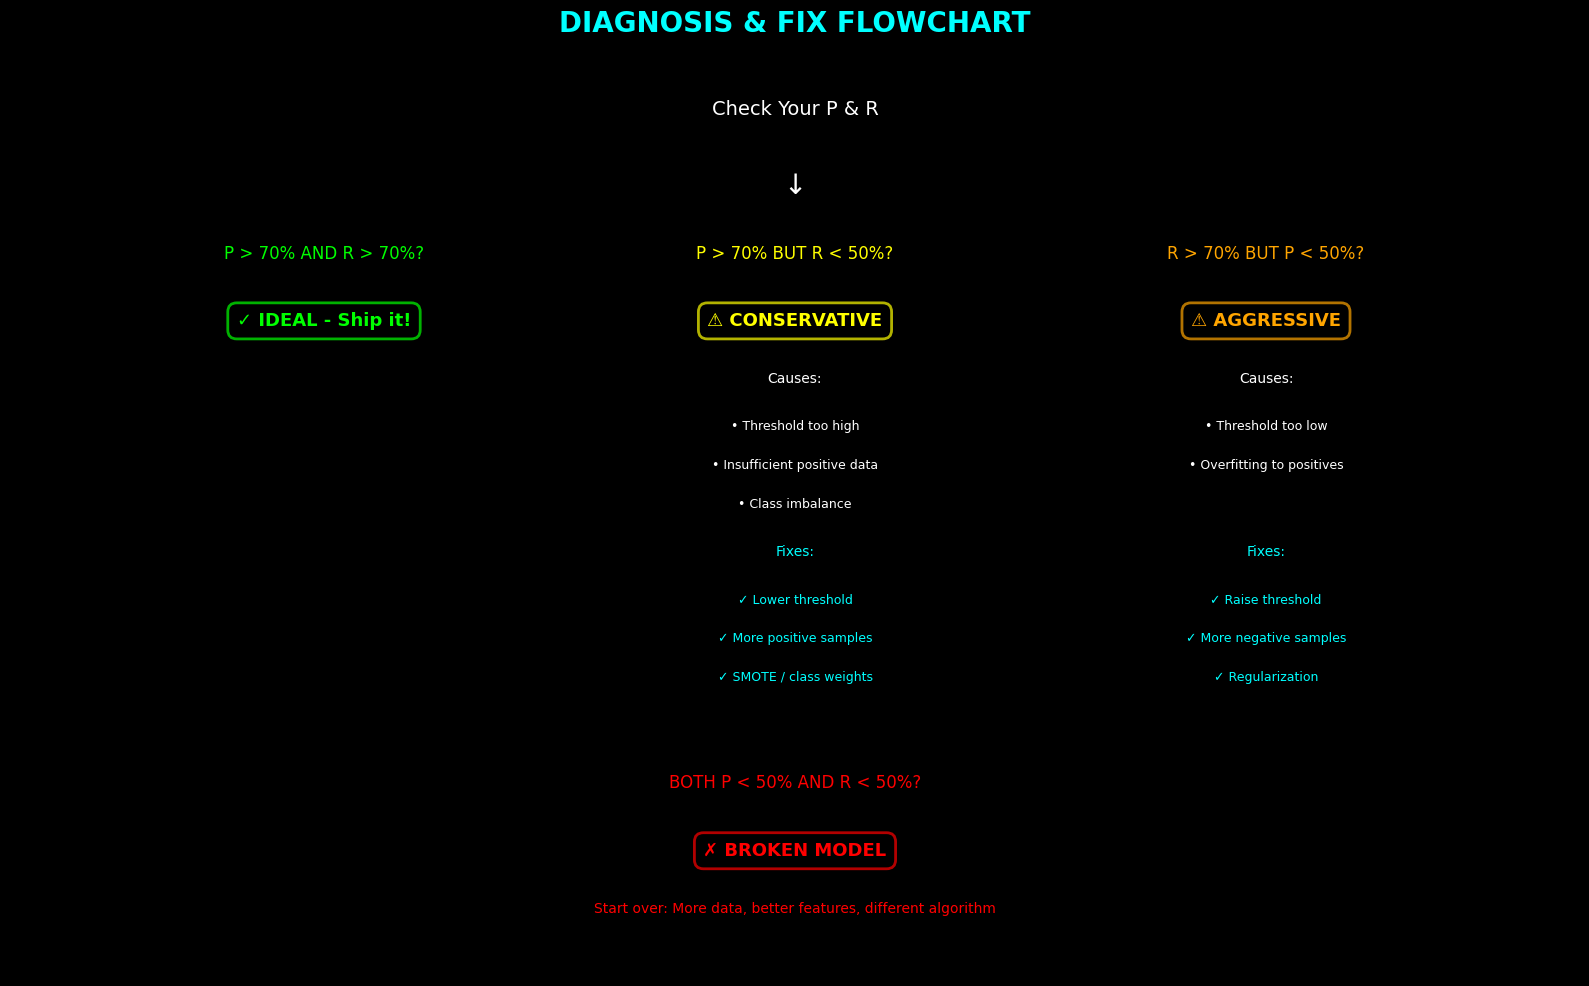

In [8]:
fig, ax = plt.subplots(figsize=(16, 10))

# Title
ax.text(0.5, 0.98, 'DIAGNOSIS & FIX FLOWCHART', 
       transform=ax.transAxes, ha='center', fontsize=20, 
       fontweight='bold', color='cyan')

# The flowchart
flowchart = [
    {'y': 0.90, 'text': 'Check Your P & R', 'color': 'white', 'size': 14},
    {'y': 0.82, 'text': '↓', 'color': 'white', 'size': 20},
    
    # High P, High R
    {'y': 0.75, 'x': 0.2, 'text': 'P > 70% AND R > 70%?', 'color': 'lime', 'size': 12},
    {'y': 0.68, 'x': 0.2, 'text': '✓ IDEAL - Ship it!', 'color': 'lime', 'size': 13, 'bold': True},
    
    # High P, Low R
    {'y': 0.75, 'x': 0.5, 'text': 'P > 70% BUT R < 50%?', 'color': 'yellow', 'size': 12},
    {'y': 0.68, 'x': 0.5, 'text': '⚠️ CONSERVATIVE', 'color': 'yellow', 'size': 13, 'bold': True},
    {'y': 0.62, 'x': 0.5, 'text': 'Causes:', 'color': 'white', 'size': 10},
    {'y': 0.57, 'x': 0.5, 'text': '• Threshold too high', 'color': 'white', 'size': 9},
    {'y': 0.53, 'x': 0.5, 'text': '• Insufficient positive data', 'color': 'white', 'size': 9},
    {'y': 0.49, 'x': 0.5, 'text': '• Class imbalance', 'color': 'white', 'size': 9},
    {'y': 0.44, 'x': 0.5, 'text': 'Fixes:', 'color': 'cyan', 'size': 10},
    {'y': 0.39, 'x': 0.5, 'text': '✓ Lower threshold', 'color': 'cyan', 'size': 9},
    {'y': 0.35, 'x': 0.5, 'text': '✓ More positive samples', 'color': 'cyan', 'size': 9},
    {'y': 0.31, 'x': 0.5, 'text': '✓ SMOTE / class weights', 'color': 'cyan', 'size': 9},
    
    # Low P, High R
    {'y': 0.75, 'x': 0.8, 'text': 'R > 70% BUT P < 50%?', 'color': 'orange', 'size': 12},
    {'y': 0.68, 'x': 0.8, 'text': '⚠️ AGGRESSIVE', 'color': 'orange', 'size': 13, 'bold': True},
    {'y': 0.62, 'x': 0.8, 'text': 'Causes:', 'color': 'white', 'size': 10},
    {'y': 0.57, 'x': 0.8, 'text': '• Threshold too low', 'color': 'white', 'size': 9},
    {'y': 0.53, 'x': 0.8, 'text': '• Overfitting to positives', 'color': 'white', 'size': 9},
    {'y': 0.44, 'x': 0.8, 'text': 'Fixes:', 'color': 'cyan', 'size': 10},
    {'y': 0.39, 'x': 0.8, 'text': '✓ Raise threshold', 'color': 'cyan', 'size': 9},
    {'y': 0.35, 'x': 0.8, 'text': '✓ More negative samples', 'color': 'cyan', 'size': 9},
    {'y': 0.31, 'x': 0.8, 'text': '✓ Regularization', 'color': 'cyan', 'size': 9},
    
    # Low P, Low R
    {'y': 0.20, 'x': 0.5, 'text': 'BOTH P < 50% AND R < 50%?', 'color': 'red', 'size': 12},
    {'y': 0.13, 'x': 0.5, 'text': '✗ BROKEN MODEL', 'color': 'red', 'size': 13, 'bold': True},
    {'y': 0.07, 'x': 0.5, 'text': 'Start over: More data, better features, different algorithm', 
     'color': 'red', 'size': 10},
]

for item in flowchart:
    x = item.get('x', 0.5)
    bold = item.get('bold', False)
    weight = 'bold' if bold else 'normal'
    
    ax.text(x, item['y'], item['text'], 
           transform=ax.transAxes, ha='center', va='center',
           fontsize=item['size'], color=item['color'],
           fontweight=weight,
           bbox=dict(boxstyle='round,pad=0.5', 
                    facecolor='black', alpha=0.7, 
                    edgecolor=item['color'], linewidth=2) if bold else None)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.show()

## 8. Key Takeaways

### The 4 Quadrants Summary:

| Scenario | Precision | Recall | Status | Main Issue | Primary Fix |
|----------|-----------|--------|--------|------------|-------------|
| **IDEAL** | High (>70%) | High (>70%) | ✓ Good | None | Ship it! |
| **CONSERVATIVE** | High (>70%) | Low (<50%) | ⚠️ Risky | High FN (misses cases) | Lower threshold, more positive data |
| **AGGRESSIVE** | Low (<50%) | High (>70%) | ⚠️ Annoying | High FP (false alarms) | Raise threshold, regularize |
| **BROKEN** | Low (<50%) | Low (<50%) | ✗ Useless | Both FP & FN high | Start over, fundamental issues |

### What "CONSERVATIVE" Means:

**Definition:**
- Model is **risk-averse**
- Only predicts positive with **very high confidence**
- Prefers to say "NO" when uncertain
- **High Precision, Low Recall** pattern

**Analogy:**
- Like a cautious doctor who only diagnoses disease when 99% sure
- Better to miss a case than wrongly alarm someone
- Conservative = "When in doubt, say negative"

**Why It Happens:**
1. **Threshold too high** (>0.7)
2. **Insufficient positive training examples** - model hasn't learned diverse positive patterns
3. **Class imbalance** - training data skewed toward negatives
4. **Poor positive class features** - hard to distinguish positives

### Low Recall Due to Insufficient Training Data:

**The Mechanism:**
```
Few Positive Examples in Training
          ↓
Model can't learn diverse positive patterns
          ↓
Only recognizes "obvious" positives
          ↓
Misses subtle/edge-case positives
          ↓
HIGH FALSE NEGATIVES
          ↓
LOW RECALL
```

**Example:**
- Training: Only 10 cancer images (all advanced stage)
- Model learns: "Cancer = large tumor"
- Testing: Early-stage cancer (small tumor)
- Result: Model says "healthy" → **False Negative**
- **Low Recall** because model misses early-stage cases it never saw

**Solution:**
- Collect **more diverse positive examples**
- Include edge cases, subtle cases, early-stage cases
- Use **data augmentation** (SMOTE, synthetic generation)
- Apply **class weights** to amplify limited positive samples

### Quick Diagnosis Checklist:

**Step 1:** Calculate P and R on validation set

**Step 2:** Identify quadrant:
- Both >70%? → ✓ Great!
- P high, R low? → Conservative (lower threshold, more positive data)
- R high, P low? → Aggressive (raise threshold)
- Both low? → Broken (fundamental fix needed)

**Step 3:** Check confusion matrix:
- High FN? → Recall problem
- High FP? → Precision problem
- Both high? → Model is broken

**Step 4:** Investigate root cause:
- Plot ROC curve → Is there a better threshold?
- Check class distribution → Imbalance?
- Count positive samples → Enough data?
- Examine errors → Systematic pattern?

**Step 5:** Apply appropriate fix (see flowchart above)

### Remember:
- **Precision** = "Am I right when I say YES?"
- **Recall** = "Do I find all the YES cases?"
- **Conservative** = High precision, low recall (too careful)
- **Aggressive** = Low precision, high recall (too loose)
- **Context decides** which error (FP vs FN) is more costly
- **Insufficient data** → Conservative model → Low recall

**The golden rule:** Always check BOTH metrics, not just accuracy! 🎯